In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.special import softmax
import seaborn as sns
from collections import defaultdict
import os
from terminal_pareto import ParetoFront
import matplotlib as mpl
from pyreadr import read_r
from scipy.stats import spearmanr
from sklearn.decomposition import PCA

mpl.rcParams['figure.dpi'] = 300

t_threshold = 255
tracking_scale = 0.1625
ts_df = pd.read_csv("./data/embryo1/tracks.txt", sep="\t")
ts_df = ts_df.loc[ts_df["t"] <= t_threshold]
all_xyz_map = {}
cell_names = ts_df["name"].unique()
valid_cell_names = []
cutoff_terminals = []
for name in cell_names:
    time_points = ts_df.loc[ts_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        continue
    if time_points[-1] == t_threshold:
        cutoff_terminals.append(name)
    all_xyz_map[name] = ts_df.loc[ts_df['name'] == name].values[-1][1:4]*tracking_scale
    valid_cell_names.append(name)

# name mapping
def map_names(did):
    """ Re-map cells to use their 'name' given their 'did'. Only applies to a
        few select cells where the tracker uses their 'name' instead of 'did'.
    """
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

embryonic_terminal_cells = pd.read_csv('data/embryonic_terminals.txt', sep='\t', header=None)[0].tolist()
include_embryonic_terminals = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


if   EMBRYO==1: TSTOP=250

elif EMBRYO==2: TSTOP=242

elif EMBRYO==3: TSTOP=221

In [7]:
# lineage_exp = read_r("./data/viscello/lin_sc_expr_190602.rds")[None]
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_adj_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_raw_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_umap_embedding.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/binned_tenth_lineage_adj_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/binned_lineage_adj_exp_umap_embedding_3d.csv", index_col=0)
# lineage_exp = pd.read_csv("data/protein/aggregated_all/binned_lineage_adj_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/lineage_umap_embedding_s3.csv", index_col=0)
lineage_exp_alt = pd.read_csv("./data/protein/aggregated_all/s3_pca_10d.csv", index_col=0).T
lineage_exp = pd.read_csv("data/c_briggsae/science.adu8249/c_elegans_tf_pca_20d.csv", index_col=0).T
binary_lineage_exp = pd.read_csv("./data/protein/aggregated_all/lineage_binary_expression.csv", index_col=0)
binary_lineage_end_exp = pd.read_csv("./data/protein/aggregated_all/lineage_end_binary_expression.csv", index_col=0)
# fill nan with 0
lineage_exp = lineage_exp.fillna(0)

In [8]:
lineage_exp = read_r("./data/viscello/lin_sc_expr_190602.rds")[None]
pca = PCA(n_components=20)
res = pca.fit_transform(lineage_exp.T)
lineage_exp = pd.DataFrame(res, index=lineage_exp.columns, columns=[f'PC{i+1}' for i in range(20)]).T
lineage_exp.head()

,ABala,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalp,ABalaaaar,ABalaaaarl,ABalaaaarlp,...,MSpppapp,MSpppp,MSppppa,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,Z2,Z3
PC1,12.372923,12.777117,9.683334,7.561822,1.898925,-8.115877,1.154707,7.669419,2.829611,-7.767651,...,-9.587578,8.472981,-0.727594,-10.012177,-9.867612,-0.932072,-9.361151,-10.184823,0.572117,0.572117
PC2,-1.637791,0.456475,2.914534,4.296341,8.115812,8.473096,5.258554,4.372360,5.649572,6.558767,...,-6.083925,-2.159361,-3.561262,-6.249607,-6.232439,-3.943719,-6.760067,-6.828121,-2.274986,-2.274986
PC3,1.232879,1.223755,0.591033,0.175844,-1.173702,-3.277107,-1.727981,0.203114,-0.726378,-2.822199,...,11.029821,3.112081,8.835209,12.128218,11.809328,8.690717,12.551793,12.501768,0.704601,0.704601
PC4,13.988550,6.750584,2.098812,-2.921499,-4.340956,2.483692,-5.222770,-2.085118,-5.258321,1.920272,...,0.741019,1.729102,-4.012244,0.299748,0.108358,-3.057516,0.404575,0.817030,6.077363,6.077363
PC5,-0.823799,-1.495377,-1.385209,-0.465676,-1.364231,-0.489904,0.121747,-0.391040,-0.280750,-0.419261,...,1.078292,0.369589,-0.513585,-0.792381,-0.630511,-0.107954,-0.745709,-0.632325,4.379912,4.379912


In [9]:
lineage_exp = pd.read_csv("./data/protein/aggregated_all/embeddings_32d.csv", index_col=0).T

In [10]:
last_seen_time = defaultdict(int)
graph_by_time = defaultdict(dict) # time -> {cell_id: [neighbor_ids]}
for file in tqdm(os.listdir("data/nat_comm/MT_wee-1.1_1_GuiNeighbor/")):
    if file.endswith(".txt"):
        cur_time = int(file.split("_")[3])
        with open(os.path.join("data/nat_comm/MT_wee-1.1_1_GuiNeighbor/", file), 'r') as f:
            lines = f.readlines()
            for line in lines[1:]:
                cell_ids = [int(part) for part in line.strip().split(",")]
                cur_cell = cell_ids[0]
                neighbors = cell_ids[1:]
                graph_by_time[cur_time][cur_cell] = neighbors
                last_seen_time[cur_cell] = max(last_seen_time[cur_cell], cur_time)

100%|██████████| 125/125 [00:00<00:00, 4342.97it/s]


In [11]:
neighbor_id_mapping = pd.read_csv("data/nat_comm/name_dictionary.csv", index_col=0).to_dict()['name']
name_to_neighbor_id = { v: k for k, v in neighbor_id_mapping.items() }

In [12]:
lineages_with_neighbors = set()
for id in last_seen_time.keys():
    lineages_with_neighbors.add(neighbor_id_mapping[id])

In [13]:
len(lineages_with_neighbors)

639

In [14]:
neighbor_tracking_times = [t for t in graph_by_time.keys()]
neighbor_tracking_times.sort()

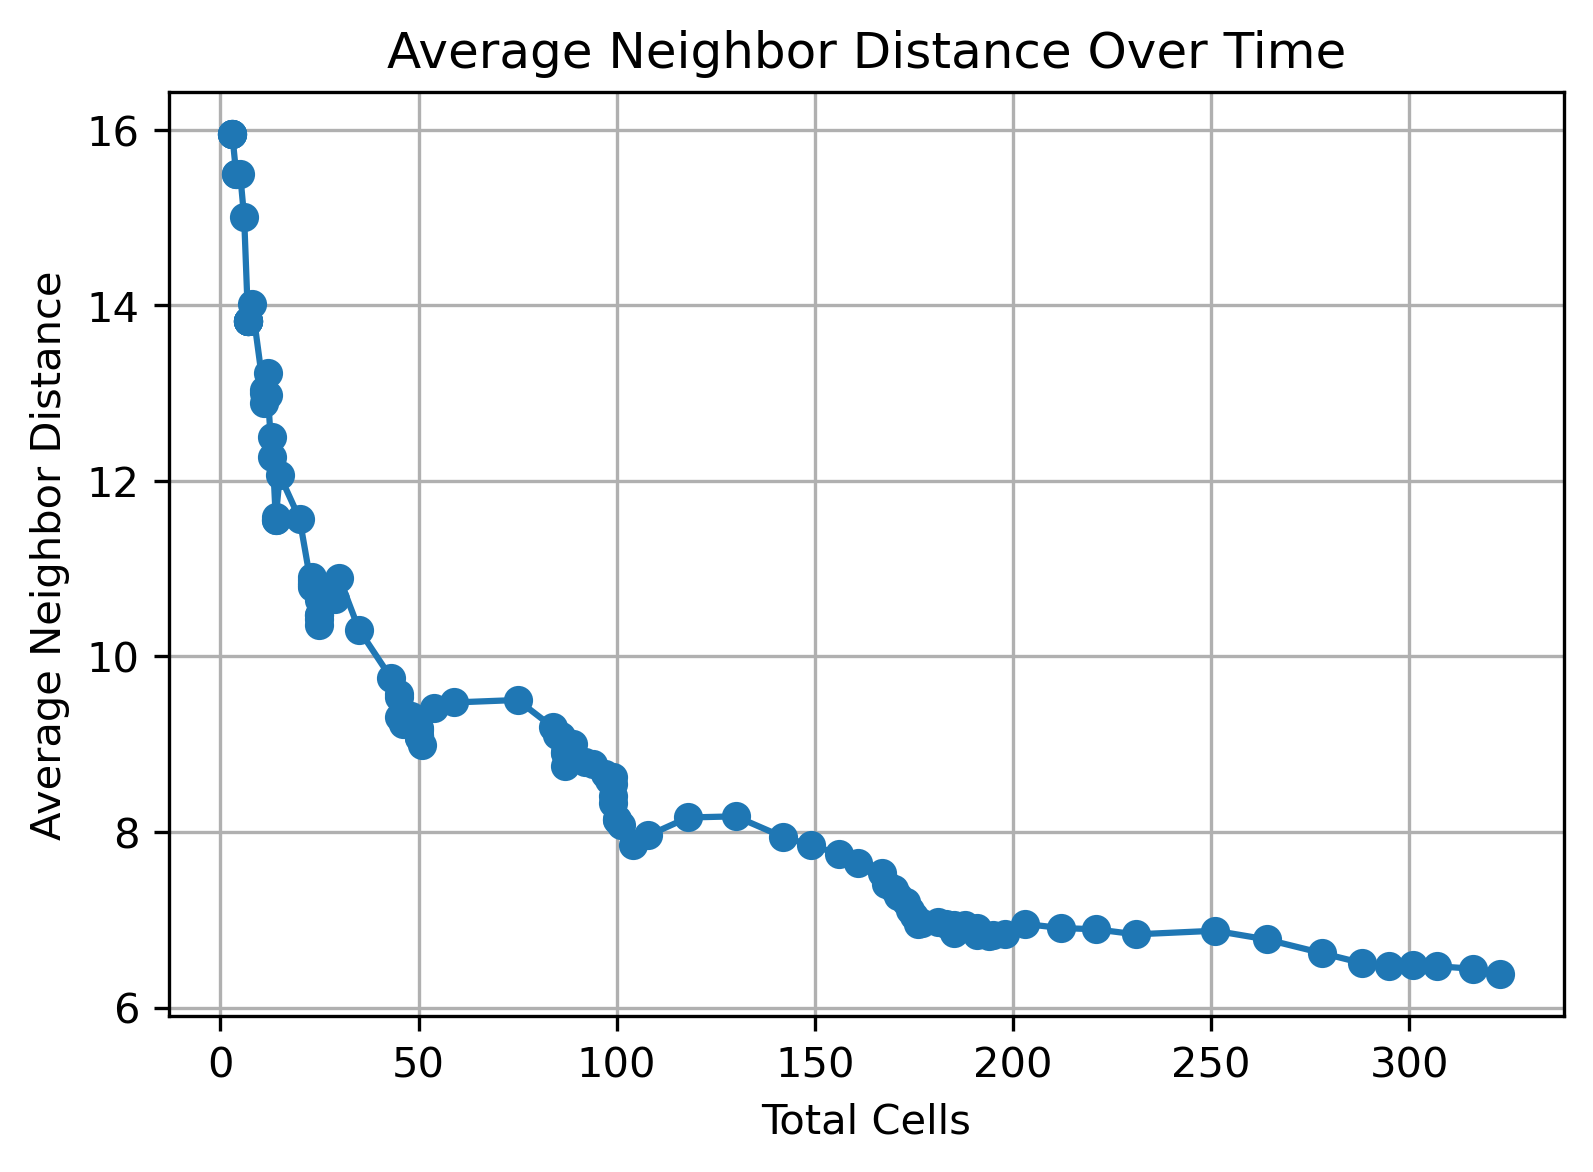

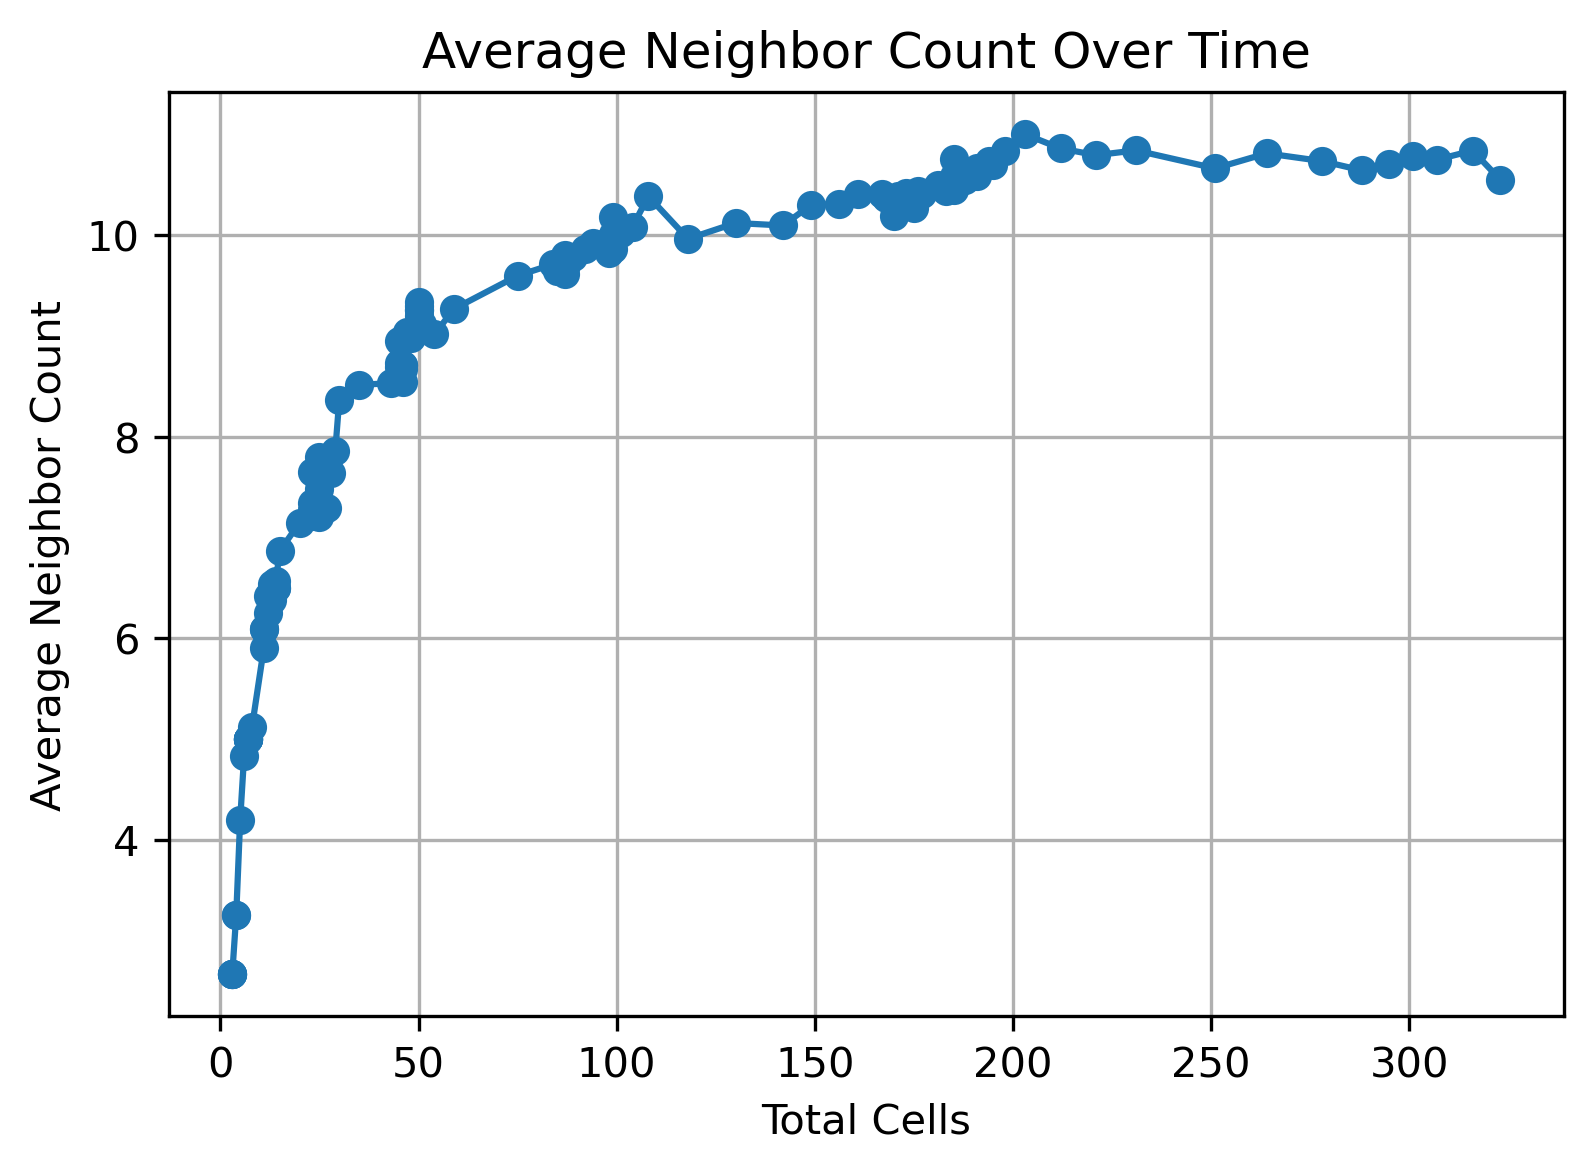

In [15]:
avg_neighbor_distance_list = []
avg_neighbor_count_list = []
total_cells_list = []
for time in neighbor_tracking_times:
    total_distance = 0
    total_count = 0
    graph = graph_by_time[time]
    for i in graph_by_time[time].keys():
        total_count += len(graph_by_time[time][i])
        neighbors = graph_by_time[time][i]
        name_i = neighbor_id_mapping[i]
        for j in neighbors:
            name_j = neighbor_id_mapping[j]
            edge_ij = np.linalg.norm(all_xyz_map[name_i] - all_xyz_map[name_j])
            total_distance += edge_ij
    avg_distance = total_distance / total_count
    avg_neighbor_count = total_count / len(graph_by_time[time].keys())
    avg_neighbor_distance_list.append(avg_distance)
    avg_neighbor_count_list.append(avg_neighbor_count)
    total_cells_list.append(len(graph_by_time[time].keys()))
plt.figure(figsize=(6,4))
plt.plot(total_cells_list, avg_neighbor_distance_list, marker='o')
plt.xlabel("Total Cells")
plt.ylabel("Average Neighbor Distance")
plt.title("Average Neighbor Distance Over Time")
plt.grid()

plt.figure(figsize=(6,4))
plt.plot(total_cells_list, avg_neighbor_count_list, marker='o')
plt.xlabel("Total Cells")
plt.ylabel("Average Neighbor Count")
plt.title("Average Neighbor Count Over Time")
plt.grid()

In [16]:
# expression data with only valid TFs
# lineage_exp = lineage_exp.loc[valid_tf_names]
lineage_names_with_exp = lineage_exp.columns.values
name_to_idx = {name: idx for idx, name in enumerate(lineage_exp.columns)}
expression_softmax = softmax(lineage_exp.values, axis=0)
lineage_softmax_exp = lineage_exp.copy()
lineage_softmax_exp.iloc[:,:] = expression_softmax

In [17]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
count = 0
lineage_type_dict = defaultdict(str)
for lineage in lineage_exp.columns:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    # remove nan from cur_lineage_types
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()]
    cur_lineage_types = cur_lineage_types.unique()
    if len(cur_lineage_types) == 0:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    lineage_type_dict[lineage] = cur_lineage_types[0]

In [18]:
import json

def load_json(file_path):
    """
    Load a JSON file and return its content as a Python object.
    
    :param file_path: Path to the JSON file.
    :return: Parsed JSON content as a Python object.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
lineage_data = load_json('./data/cell_lineage.json')


In [19]:
from collections import defaultdict
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    # using cutoff terminals rather so that all neighbors are included, 
    # otherwise we would miss some neighbors that are not terminal in the full tree
    if lookup_name in cutoff_terminals and lookup_name in lineage_exp.columns:
        p_lookup_name = map_names(parent['did'])
        if p_lookup_name not in lineage_exp.columns:
            return
        terminal_nodes.append(lookup_name)
        terminal_parents.append(p_lookup_name)
        terminal_parents_dict[p_lookup_name].append(lookup_name)
        terminal_ancestry[len(terminal_nodes)-1] = ancestors
    else:
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)

In [20]:
def lca_distance(ancestry1: list, ancestry2: list):
    min_length = min(len(ancestry1), len(ancestry2))
    max_length = max(len(ancestry1), len(ancestry2))
    lca_index = 0
    for i in range(min_length):
        if ancestry1[i] == ancestry2[i]:
            lca_index = i
        else:
            break
    return max_length -  (lca_index + 1)

In [21]:
neighboring_distance_cutoff = 5 # debatable value, just for rough estimation
neighboring_edges = []
all_pairwise_xyz_dist = []
for i in range(len(terminal_nodes)):
    for j in range(i+1, len(terminal_nodes)):
        xyz_dist = np.linalg.norm(all_xyz_map[terminal_nodes[i]] - all_xyz_map[terminal_nodes[j]])
        if xyz_dist <= neighboring_distance_cutoff:
            neighboring_edges.append((i, j))
        all_pairwise_xyz_dist.append(xyz_dist)


In [22]:
len(neighboring_edges)

2927

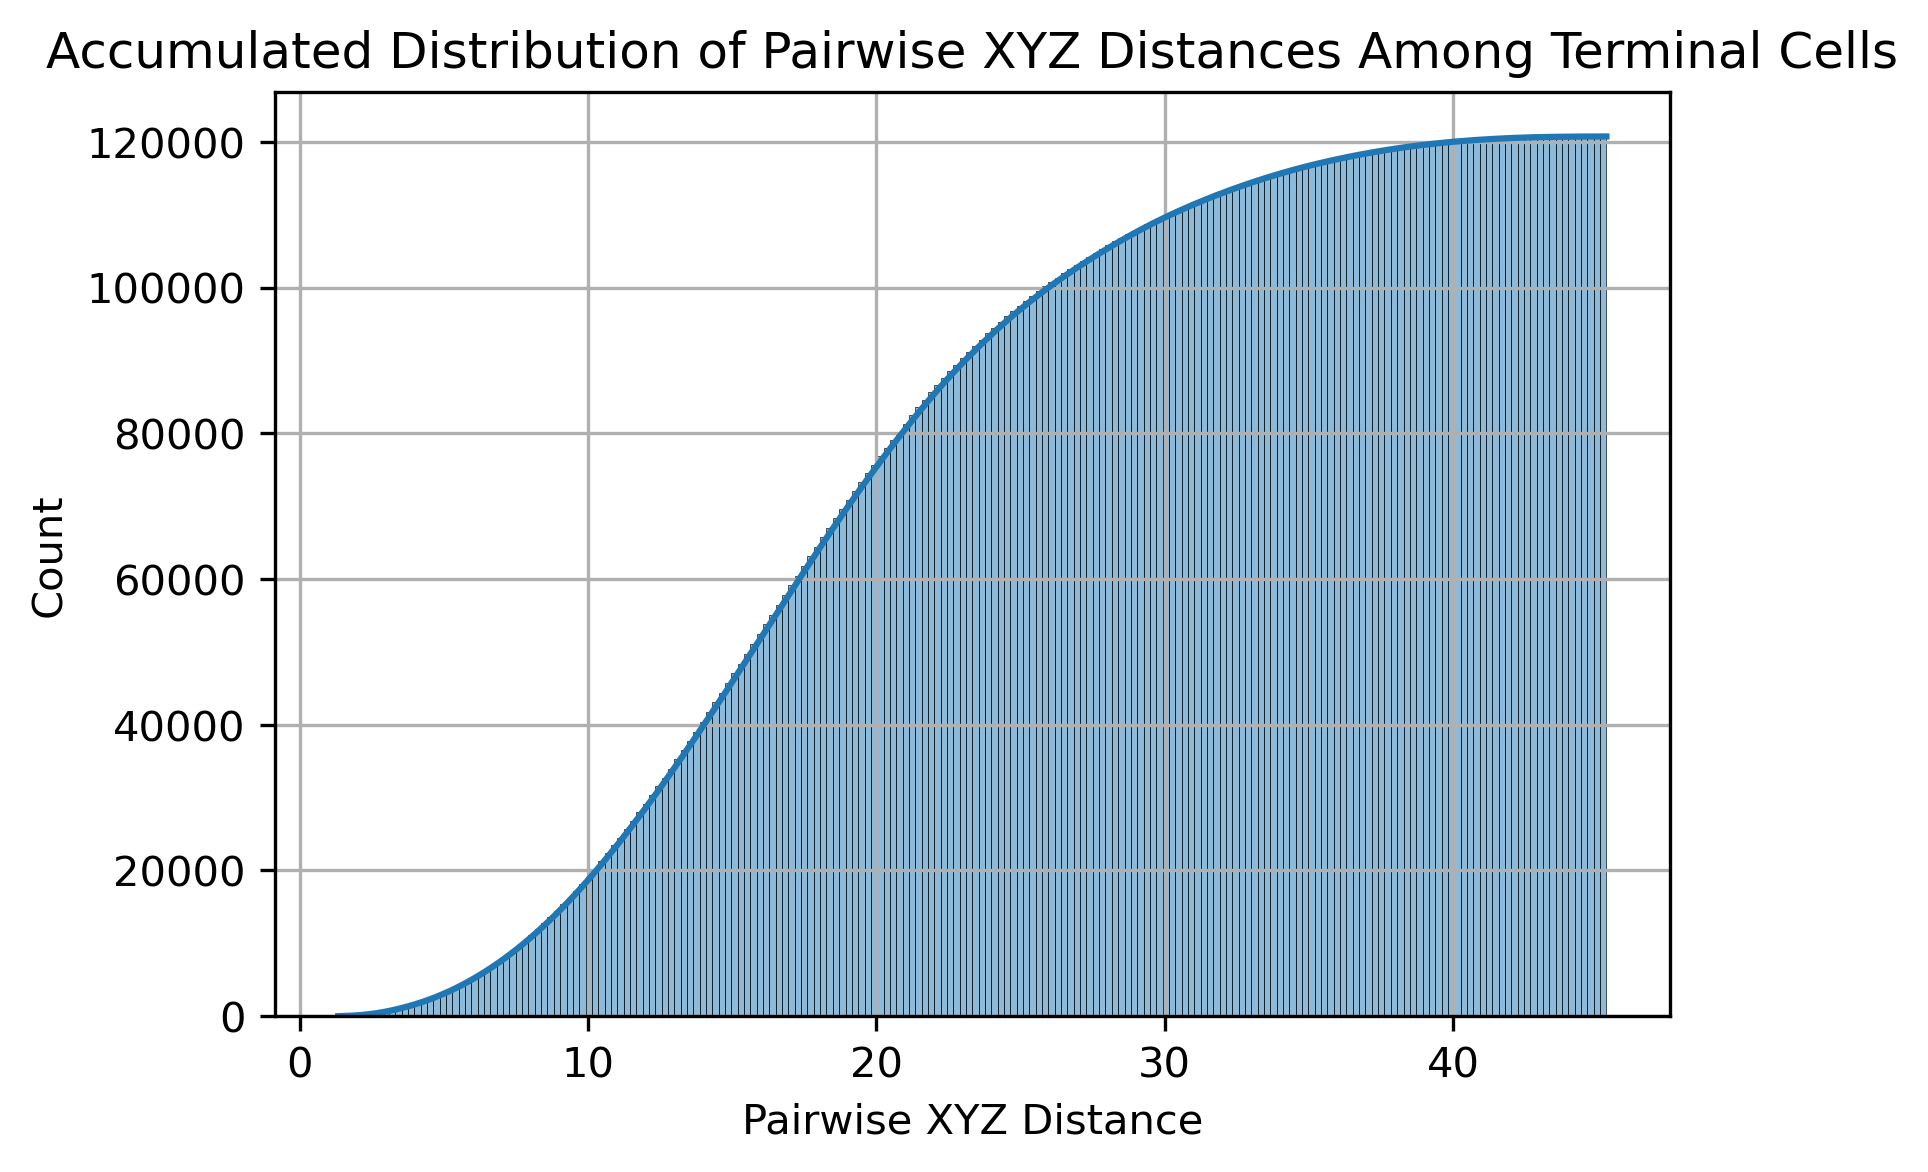

In [23]:
# plot the accumulative distribution of all_pairwise_xyz_dist
plt.figure(figsize=(6,4))
sns.histplot(all_pairwise_xyz_dist, bins=200, kde=True, cumulative=True)
plt.xlabel("Pairwise XYZ Distance")
plt.ylabel("Count")
plt.title("Accumulated Distribution of Pairwise XYZ Distances Among Terminal Cells")
plt.grid()

In [24]:
terminal_node_cords = []
terminal_parent_cords = []
xyz_coord_dict = {}
exp_vector_dict = {}
# Collect coordinates for terminal nodes and their parents

for node, parent in zip(terminal_nodes, terminal_parents):
    xyz_coord_dict[node] = ts_df.loc[ts_df['name'] == node].values[-1][1:4]*tracking_scale
    xyz_coord_dict[parent] = ts_df.loc[ts_df['name'] == parent].values[-1][1:4]*tracking_scale
    exp_vector_dict[node] = lineage_exp.loc[:, node].values
    exp_vector_dict[parent] = lineage_exp.loc[:, parent].values

In [25]:
neighbor_dict = {
    "terminal": defaultdict(set),
    "terminal_parents": defaultdict(set)
}
terminal_parent_pairwise_distances = defaultdict(dict)
for focal_cell in tqdm(terminal_parents):
    if focal_cell in neighbor_dict["terminal_parents"]:
        continue
    last_track = ts_df.loc[ts_df['name'] == focal_cell].sort_values(by='t', ascending=False).iloc[0]
    focal_cell_xyz = last_track[["x", "y", "z"]].values
    nucleus_to_cell_ratio = 2
    if focal_cell.startswith("AB") and len(focal_cell) > 8:
        nucleus_to_cell_ratio = 1.5
    focal_cell_radius = last_track["radius"] * nucleus_to_cell_ratio
    other_tracks = ts_df.loc[ts_df['t'] == last_track["t"]]
    distances_from_focal_cell = []
    for _, row in other_tracks.iterrows():
        other_cell = row["name"]
        if other_cell == focal_cell:
            continue
        other_cell_xyz = row[["x", "y", "z"]].values
        distance = np.linalg.norm(focal_cell_xyz - other_cell_xyz)
        nucleus_to_cell_ratio = 2
        if other_cell.startswith("AB") and len(other_cell) > 8:
            nucleus_to_cell_ratio = 1.5
        other_cell_radius = row["radius"] * nucleus_to_cell_ratio
        if distance <= focal_cell_radius + other_cell_radius:
            neighbor_dict["terminal_parents"][focal_cell].add(other_cell)
        distances_from_focal_cell.append((other_cell, distance))
        terminal_parent_pairwise_distances[focal_cell][other_cell] = distance * tracking_scale
    # sort distances_from_focal_cell by distance
    distances_from_focal_cell = sorted(distances_from_focal_cell, key=lambda x: x[1])
    # get the top 7 closest cells
    closest_cells = [cell for cell, dist in distances_from_focal_cell[:7]]
    for cell in closest_cells:
        neighbor_dict["terminal_parents"][focal_cell].add(cell)

100%|██████████| 492/492 [00:22<00:00, 21.82it/s]


In [34]:
terminal_track = ts_df.loc[ts_df['t'] == t_threshold]
terminal_track.index = terminal_track["name"]
for focal_cell in tqdm(terminal_nodes):
    focal_cell_xyz = terminal_track.loc[focal_cell][["x", "y", "z"]].values
    nucleus_to_cell_ratio = 2
    if focal_cell.startswith("AB") and len(focal_cell) > 8:
        nucleus_to_cell_ratio = 1.5
    focal_cell_radius = terminal_track.loc[focal_cell]["radius"] * nucleus_to_cell_ratio
    distances_from_focal_cell = []
    for other_cell in terminal_nodes:
        if other_cell == focal_cell:
            continue
        other_cell_xyz = terminal_track.loc[other_cell][["x", "y", "z"]].values
        distance = np.linalg.norm(focal_cell_xyz - other_cell_xyz)
        nucleus_to_cell_ratio = 2
        if other_cell.startswith("AB") and len(other_cell) > 8:
            nucleus_to_cell_ratio = 1.5
        other_cell_radius = terminal_track.loc[other_cell]["radius"] * nucleus_to_cell_ratio
        if distance <= focal_cell_radius + other_cell_radius:
            neighbor_dict["terminal"][focal_cell].add(other_cell)
        distances_from_focal_cell.append((other_cell, distance))
    # sort distances_from_focal_cell by distance
    distances_from_focal_cell = sorted(distances_from_focal_cell, key=lambda x: x[1])
    # get the top 7 closest cells
    closest_cells = [cell for cell, dist in distances_from_focal_cell[:7]]
    for cell in closest_cells:
        neighbor_dict["terminal"][focal_cell].add(cell)

100%|██████████| 378/378 [00:41<00:00,  9.07it/s]


In [ ]:
wt_parent_dict = {terminal: parent for terminal, parent in zip(terminal_nodes, terminal_parents)}
wt_children_dict = defaultdict(list)
for terminal, parent in zip(terminal_nodes, terminal_parents):
    wt_children_dict[parent].append(terminal)

In [36]:
new_pf = ParetoFront(terminal_nodes, terminal_parents, terminal_ancestry, xyz_coord_dict, lineage_exp, binary_lineage_exp, binary_lineage_end_exp, title="Pareto Front of 299 Terminal Cells")

In [68]:
alt_exp_vector_dict = {}
for node in lineage_exp_alt.columns:
    alt_exp_vector_dict[node] = lineage_exp_alt.loc[:, node].values

pareto_xyz_cost_list, pareto_exp_cost_list, pareto_alt_exp_cost_list = new_pf.pareto_front_with_alt_exp(alt_exp_vector_dict=alt_exp_vector_dict)

100%|██████████| 378/378 [00:00<00:00, 496.24it/s]


In [57]:
zipped = [(np.round(a, 5), np.round(b, 5)) for a, b in zip(pareto_exp_cost_list, pareto_alt_exp_cost_list)]
unique_pairs = []
seen_pairs = set()
for pair in zipped:
    if pair in seen_pairs:
        continue
    seen_pairs.add(pair)
    unique_pairs.append(pair)

In [69]:
exp_list = []
alt_exp_list = []
for a, b in unique_pairs:
    exp_list.append(a)
    alt_exp_list.append(b)
r, p = spearmanr(pareto_alt_exp_cost_list, pareto_exp_cost_list)
print(f"Spearman correlation between Alt Exp Costs and Exp Costs: r = {r}, p = {p}")

Spearman correlation between Alt Exp Costs and Exp Costs: r = -0.7922119508827473, p = 1.6688315382242395e-216


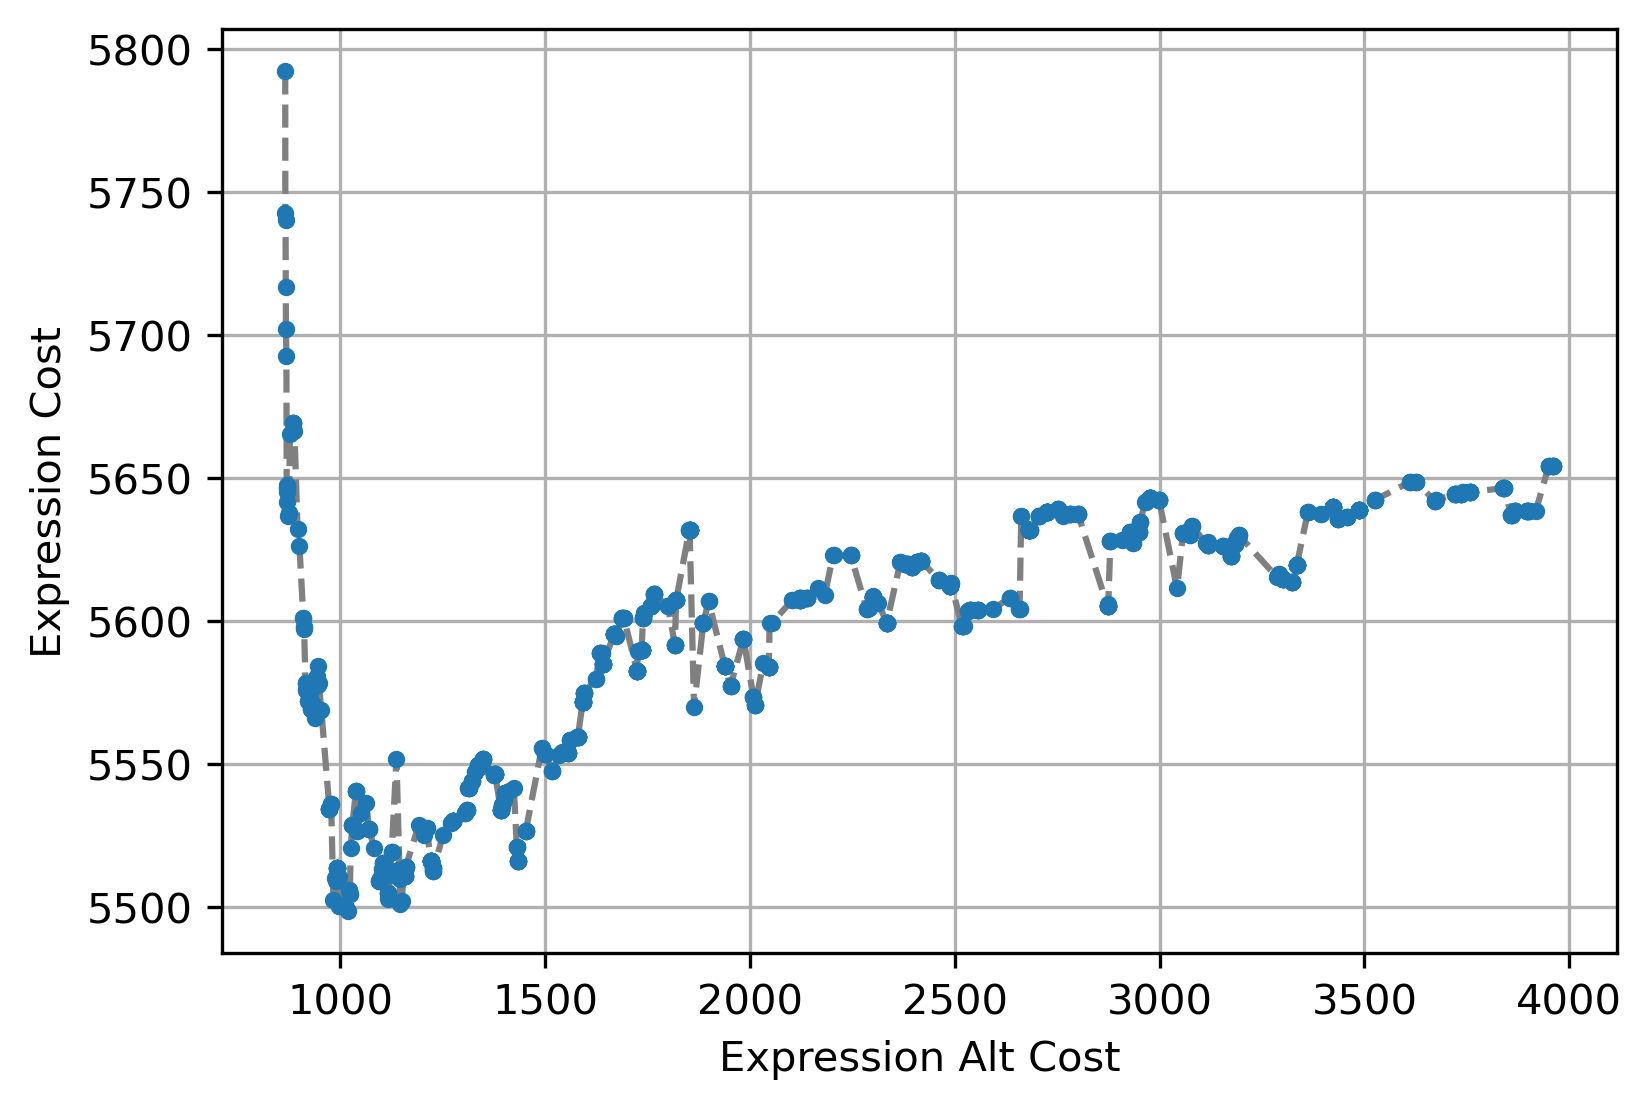

In [72]:
plt.figure(figsize=(6,4))   
plt.scatter(pareto_xyz_cost_list, pareto_exp_cost_list, s=10, zorder=10)
plt.plot(pareto_xyz_cost_list, pareto_exp_cost_list,  label='Pareto Front', markersize=0, linestyle='dashed', color='gray')

plt.xlabel("Expression Alt Cost")
plt.ylabel("Expression Cost")
plt.grid()

In [46]:
def remove_duplicates(arr):
    _, idx = np.unique(arr, return_index=True)
    return arr[np.sort(idx)]

In [47]:
r, p = spearmanr(remove_duplicates(np.array(pareto_exp_cost_list)), remove_duplicates(np.array(pareto_alt_exp_cost_list)))
print(f"Spearman correlation between Alt Exp Costs and Exp Costs: r = {r}, p = {p}")

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 297 and the array at index 1 has size 330

In [39]:
pareto_alt_exp_cost_list[-1], pareto_exp_cost_list[-1], pareto_xyz_cost_list[-1]

(np.float64(49908.304356572655),
 np.float64(5792.323730728622),
 np.float64(865.6083317662219))

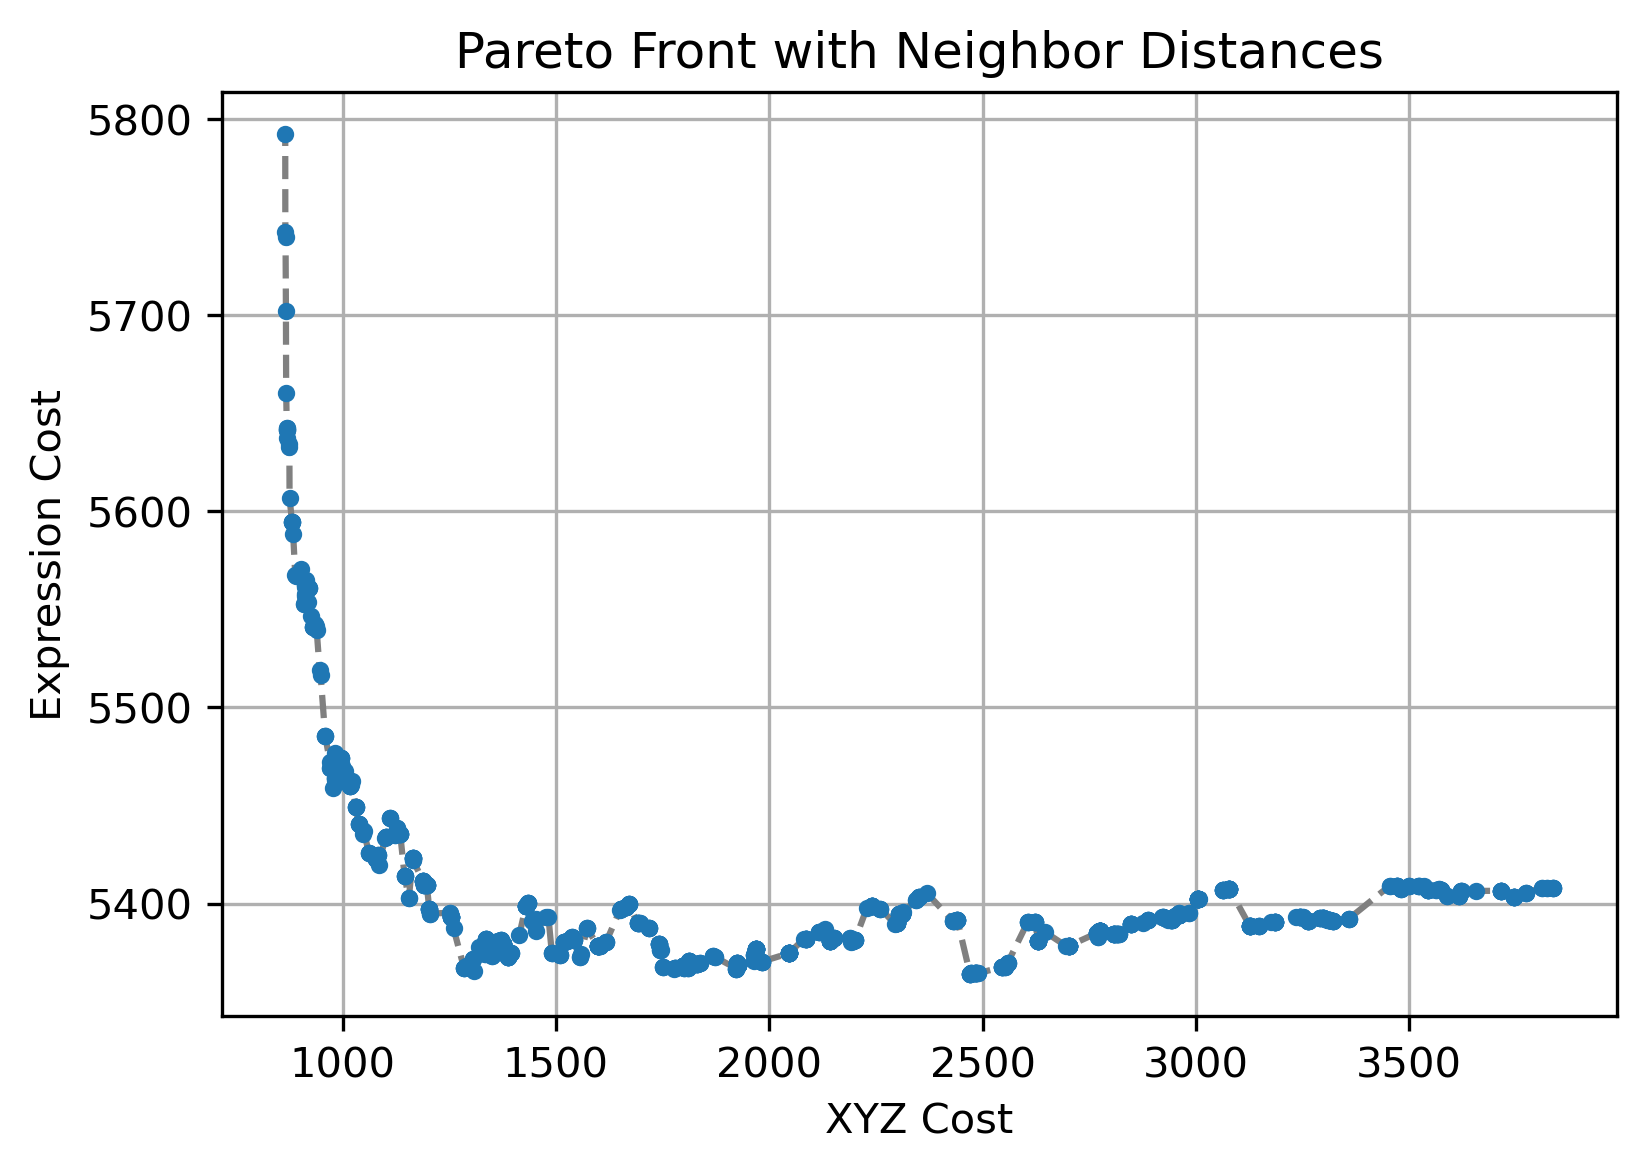

In [41]:
plt.figure(figsize=(6,4))   
plt.scatter(pareto_xyz_cost_list, pareto_exp_cost_list, s=10, zorder=10)
plt.plot(pareto_xyz_cost_list, pareto_exp_cost_list,  label='Pareto Front', markersize=0, linestyle='dashed', color='gray')

plt.xlabel("XYZ Cost")
plt.ylabel("Expression Cost")
plt.title("Pareto Front with Neighbor Distances")
plt.grid()

In [329]:
lineage_neighbor_change_distance = new_pf.calculate_neighbor_change_distances(neighbor_dict, terminal_parent_pairwise_distances, wt_children_dict, wt_parent_dict)

In [330]:
res = new_pf.pareto_front_with_neighbors(neighbor_edges=neighboring_edges, neighbor_dict=neighbor_dict, terminal_parent_pairwise_distances=terminal_parent_pairwise_distances)

100%|██████████| 370/370 [00:01<00:00, 316.78it/s]


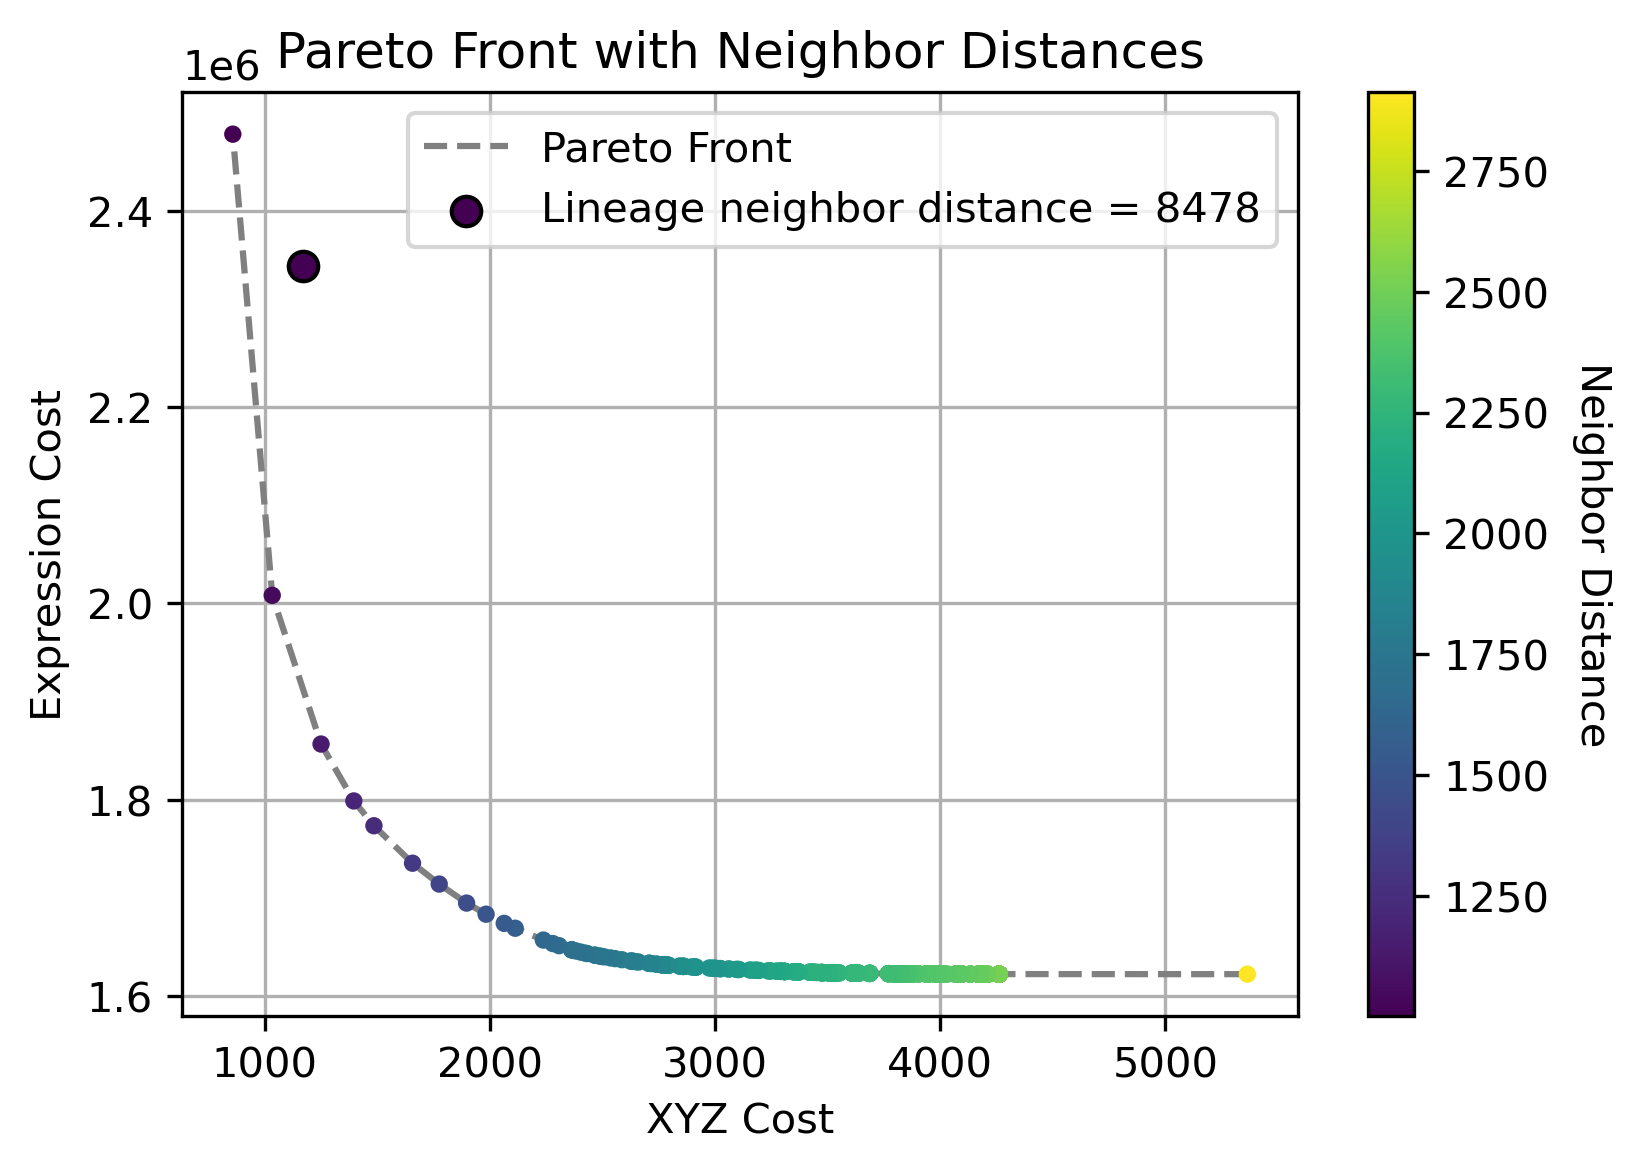

In [331]:
# plot the pareto front together with lineage costs with neighbor distances, color by neighbor distances
pareto_xyz_costs, pareto_exp_costs, pareto_neighbor_distances, lineage_xyz_cost, lineage_exp_cost, lineage_neighbor_distance, pareto_neighbor_change_distances = res
plt.figure(figsize=(6,4))   
plt.scatter(pareto_xyz_costs, pareto_exp_costs, c=pareto_neighbor_change_distances, cmap='viridis', s=10, zorder=10)
plt.plot(pareto_xyz_costs, pareto_exp_costs,  label='Pareto Front', markersize=0, linestyle='dashed', color='gray')
cbar = plt.colorbar()
cbar.set_label('Neighbor Distance', rotation=270, labelpad=15)
plt.xlabel("XYZ Cost")
plt.ylabel("Expression Cost")
plt.title("Pareto Front with Neighbor Distances")
plt.grid()
plt.scatter([lineage_xyz_cost], [lineage_exp_cost], c=[lineage_neighbor_change_distance], cmap='viridis', s=50, edgecolor='black', label=f'Lineage neighbor distance = {lineage_neighbor_distance}')
plt.legend()

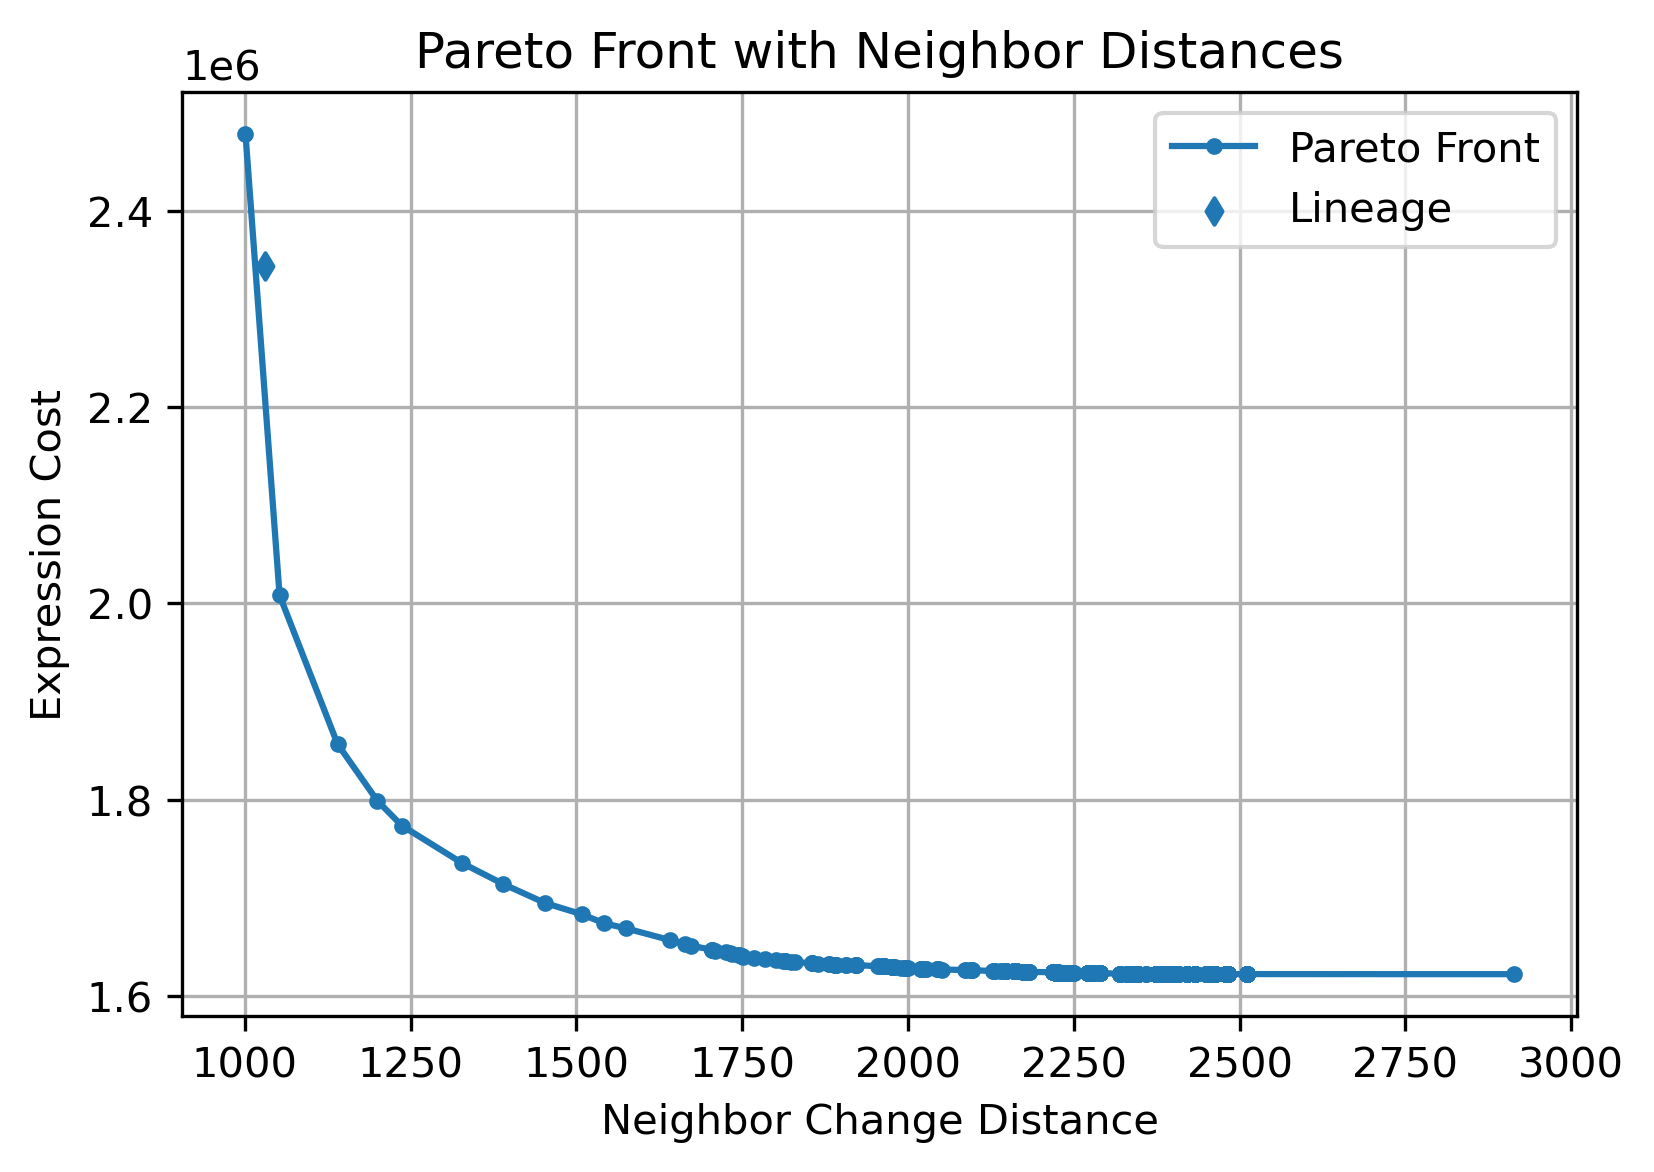

In [332]:
plt.figure(figsize=(6,4))   
plt.plot(pareto_neighbor_change_distances, pareto_exp_costs,  label='Pareto Front', marker='o', linestyle='-', markersize=3)
plt.xlabel("Neighbor Change Distance")
plt.ylabel("Expression Cost")
plt.title("Pareto Front with Neighbor Distances")
plt.grid()
plt.scatter([lineage_neighbor_change_distance], [lineage_exp_cost],  s=20, marker='d', label=f'Lineage')
plt.legend()

In [ ]:
r,p = spearmanr(pareto_xyz_costs, pareto_neighbor_distances)
print(f"Spearman correlation between XYZ costs and Neighbor Distances: r = {r}, p = {p}")
r,p = spearmanr(pareto_xyz_costs, pareto_neighbor_change_distances)
print(f"Spearman correlation between XYZ costs and Neighbor Change Distances: r = {r}, p = {p}")
r,p = spearmanr(pareto_neighbor_change_distances, pareto_neighbor_distances)
print(f"Spearman correlation between Neighbor Change Distances and Neighbor Distances: r = {r}, p = {p}")

Spearman correlation between XYZ costs and Neighbor Distances: r = 0.7120185608425018, p = 1.3777904451428293e-155
Spearman correlation between XYZ costs and Neighbor Change Distances: r = 0.9941812097263935, p = 0.0
Spearman correlation between Neighbor Change Distances and Neighbor Distances: r = 0.7068741958282377, p = 2.1400679705602676e-152


In [220]:
lineage_xyz_cost, lineage_neighbor_distance, lineage_neighbor_change_distance

(np.float64(1504.0616370827283), 15900, np.float64(1292.1461691720529))

In [221]:
pareto_xyz_costs[-1], pareto_neighbor_distances[-1], pareto_neighbor_change_distances[-1]

(np.float64(1072.562235360066), 17285, np.float64(1240.920531256915))

In [57]:
cell_names = ts_df["name"].unique()
lineage_xyz_df = pd.DataFrame(columns=["x", "y", "z"])
lineage_name_to_last_tracking_time = {}
for name in cell_names:
    if name not in lineage_exp.columns:
        continue
    lineage_tracks = ts_df.loc[ts_df['name'] == name]
    time_points = lineage_tracks["t"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        continue
    last_xyz_coordinates = lineage_tracks[["x", "y", "z"]].values[-1]
    last_tracking_time = lineage_tracks["t"].values[-1]
    lineage_name_to_last_tracking_time[name] = int(last_tracking_time)
    # appending last_xyz_coordinates to lineage_xyz_df as a new row with cell name as index
    lineage_xyz_df.loc[name] = last_xyz_coordinates * tracking_scale

In [71]:
lineage_xyz_df.loc['ABa'], all_xyz_map['ABa']

(x    21.1250
 y    19.1750
 z    17.3875
 Name: ABa, dtype: float64,
 array([17.3875, 19.175, 21.125], dtype=object))

In [68]:
lineage_xyz_df

,x,y,z
ABa,21.1250,19.1750,17.3875
ABp,38.1875,15.4375,18.6875
P2,53.1375,19.5000,17.5500
EMS,36.2375,27.4625,18.2000
ABar,27.6250,14.9500,24.0500
...,...,...,...
ABprpppaaaa,42.9000,18.5250,27.3000
ABplapaaaaa,30.8750,25.6750,9.2625
ABplapaaaap,34.1250,26.0000,7.6375
ABplppppppp,55.5750,25.1875,25.1875


In [55]:
lineage_exp

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
PC1,-121.853147,-103.237793,-111.789693,-111.847374,-88.664643,-44.302473,46.402286,205.266558,226.694963,199.876346,...,-11.095063,-7.084788,-34.916522,-35.833680,-48.020098,-109.116207,-115.052418,-120.478342,-130.332172,-130.264096
PC2,-60.190404,-47.900826,-49.831222,-49.787871,-31.273815,-18.453112,16.170319,60.215487,66.753339,54.127967,...,-18.921034,-18.738912,-22.567925,-30.385658,-35.711381,-50.630092,-50.858317,-54.170333,-54.771877,-54.606197
PC3,-60.055943,-30.519409,-27.926784,-6.650101,101.674196,97.861195,131.093507,25.775872,6.229868,-20.450366,...,-28.054131,-27.850180,11.910255,-43.840877,-50.209961,-37.703764,-30.459546,-34.229493,-33.175004,-31.162710
PC4,57.282464,20.999068,28.593342,33.807765,8.914312,11.105121,-1.348611,59.036942,104.647616,150.580245,...,-83.505205,-79.861481,-30.822623,-50.222688,-35.261839,28.352897,28.857751,35.934707,37.902194,37.702867
PC5,-19.157563,6.667126,5.801337,-0.999049,5.006493,0.047575,8.112621,34.410326,72.592869,67.720051,...,81.424329,100.760976,34.654510,72.338521,62.885330,2.687045,7.220488,5.048736,14.040187,14.799697
PC6,-2.438558,24.800446,21.746243,13.447652,9.184200,5.550533,-2.249358,11.163004,47.080285,44.992716,...,-55.733256,-34.076697,-26.167103,-43.313683,-41.886115,19.017309,21.470163,17.556105,14.053902,14.841883
PC7,-17.975311,-36.556912,-37.036009,-19.430514,17.007862,16.181361,22.902224,40.769059,33.755988,75.521875,...,42.295323,25.166553,20.522993,21.018671,20.401600,-34.402599,-37.870418,-32.408551,-31.910850,-32.630685
PC8,3.331925,13.750971,6.286808,1.574421,-17.724365,5.313008,20.346634,-8.259792,38.887898,-32.289789,...,15.656078,18.983488,2.039533,21.674965,19.849909,9.403906,4.447362,5.860991,-3.876703,-3.969029
PC9,1.621286,15.368082,20.799458,17.387115,18.321907,-0.268870,-18.416690,-30.880517,-33.275206,-16.636153,...,-3.248182,12.240116,3.070702,12.290413,14.022786,12.374596,20.457716,19.819332,28.616934,30.165980
PC10,-2.877484,2.235905,0.254764,-1.070612,-5.840426,0.312959,-10.499035,-15.568129,-5.406783,-4.190222,...,66.919107,51.649126,31.240303,63.975679,63.255425,-0.458477,-2.688554,-4.538676,-15.339975,-15.643832


In [72]:
new_pf.xyz_coord_dict

{'ABalaaaala': array([20.150000000000002, 26.4875, 14.137500000000001], dtype=object),
 'ABalaaaal': array([18.2, 25.1875, 12.8375], dtype=object),
 'ABalaaaalp': array([21.45, 27.625, 16.25], dtype=object),
 'ABalaaaarl': array([19.9875, 23.725, 13.8125], dtype=object),
 'ABalaaaar': array([19.0125, 20.475, 12.35], dtype=object),
 'ABalaaaarr': array([21.775000000000002, 20.3125, 14.625], dtype=object),
 'ABalaaapall': array([18.0375, 26.650000000000002, 15.600000000000001], dtype=object),
 'ABalaaapal': array([18.2, 26.4875, 14.7875], dtype=object),
 'ABalaaapalr': array([18.0375, 24.375, 14.625], dtype=object),
 'ABalaaapar': array([16.4125, 22.1, 14.137500000000001], dtype=object),
 'ABalaaapa': array([17.55, 19.6625, 13.1625], dtype=object),
 'ABalaaappl': array([19.337500000000002, 18.525000000000002, 13.975], dtype=object),
 'ABalaaapp': array([17.3875, 15.600000000000001, 14.950000000000001], dtype=object),
 'ABalaaapprl': array([22.1, 17.3875, 13.975], dtype=object),
 'ABalaaa